# 08. Treinamento de Modelos - TimeSeriesSplit & Threshold Financeiro

## 🎯 Objetivo

Implementar **treinamento de modelos de ML** seguindo as **melhores práticas para detecção de fraude**:

1. **TimeSeriesSplit**: Validação cruzada temporal (em vez de CV aleatório)
2. **Balanceamento correto**: SMOTE/RUS **dentro dos folds** de treino
3. **Threshold financeiro**: Otimização baseada em **Matriz de Custo**
4. **Curva Precision-Recall**: Métrica mais adequada que ROC para classes desbalanceadas

## 📚 Melhores Práticas Implementadas

### ✅ Ponto 8 - Balanceamento de Classes
- **SMOTE aplicado dentro dos folds de CV** (nunca no dataset completo)
- Alternativa: `scale_pos_weight` (XGBoost/LightGBM)

### ✅ Ponto 9 - Validação Temporal
- **TimeSeriesSplit** em vez de StratifiedKFold
- Simula cenário real de produção (treino no passado, teste no futuro)

### ✅ Ponto 10 - Threshold Financeiro (CRÍTICO)
- **Matriz de Custo**:
  - FN (False Negative): Custo da fraude não detectada = Valor da transação
  - FP (False Positive): Custo de bloquear cliente legítimo = Custo fixo de fricção
- **Threshold ótimo**: Minimiza custo total (não usa 0.5 padrão)
- **Precision-Recall Curve**: Mais informativa que ROC

---

## 1. Setup - Importações e Configuração

### 📦 Bibliotecas Adicionais Necessárias

Para executar todas as funcionalidades deste notebook, instale:

```bash
pip install xgboost lightgbm shap
```

Ou usando conda:
```bash
conda install -c conda-forge xgboost lightgbm shap
```

In [1]:
# Teste rápido de importação das bibliotecas
try:
    import xgboost as xgb
    print(f"✅ XGBoost {xgb.__version__} instalado com sucesso!")
except ImportError as e:
    print(f"❌ XGBoost não encontrado: {e}")

try:
    import lightgbm as lgb
    print(f"✅ LightGBM {lgb.__version__} instalado com sucesso!")
except ImportError as e:
    print(f"❌ LightGBM não encontrado: {e}")

try:
    import shap
    print(f"✅ SHAP {shap.__version__} instalado com sucesso!")
except ImportError as e:
    print(f"❌ SHAP não encontrado: {e}")

print("\n🎉 Todas as bibliotecas estão prontas para uso!")

✅ XGBoost 3.1.3 instalado com sucesso!
✅ LightGBM 4.6.0 instalado com sucesso!


c:\Users\win\OneDrive\Área de Trabalho\TCC\money_laundering\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ SHAP 0.51.0 instalado com sucesso!

🎉 Todas as bibliotecas estão prontas para uso!


In [2]:
# Configurar path para importar módulos do projeto
import sys
from pathlib import Path

notebook_dir = Path.cwd()
if notebook_dir.name == 'notebooks':
    sys.path.insert(0, str(notebook_dir.parent))

# Importar configurações do projeto
from source.config import PROJ_ROOT, get_data_path, get_model_path, get_figure_path, ensure_directories

# Garantir que os diretórios existam
ensure_directories()

print(f"✅ Projeto Root: {PROJ_ROOT}")
print(f"✅ Configurações carregadas de source/config.py")

2026-03-28 17:32:17.983 | INFO     | source.config:<module>:77 - [CONFIG] PROJ_ROOT: C:\Users\win\OneDrive\Área de Trabalho\TCC\money_laundering
2026-03-28 17:32:17.984 | INFO     | source.config:<module>:78 - [CONFIG] Python executando de: c:\Users\win\OneDrive\Área de Trabalho\TCC\money_laundering\notebooks
✅ Projeto Root: C:\Users\win\OneDrive\Área de Trabalho\TCC\money_laundering
✅ Configurações carregadas de source/config.py


In [3]:
# Importações padrão
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
import json
import joblib
from typing import Dict, Tuple

# Scikit-Learn - Validação e Métricas
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve,
    make_scorer, fbeta_score
)

# Scikit-Learn - Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier

# XGBoost e LightGBM
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost não disponível. Instale com: pip install xgboost")

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("⚠️  LightGBM não disponível. Instale com: pip install lightgbm")

# SHAP para explicabilidade
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("⚠️  SHAP não disponível. Instale com: pip install shap")

# Imbalanced-Learn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

# Configurações
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
pd.set_option('display.max_columns', None)

# Seed para reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Hiperparâmetros de negócio/modelagem
BETA = 0.5
RUS_NEG_POS_RATIO = 10.0
POS_WEIGHT_MULTIPLIER = 0.1

print("✅ Bibliotecas importadas com sucesso!")
if XGBOOST_AVAILABLE:
    print("✅ XGBoost disponível")
if LIGHTGBM_AVAILABLE:
    print("✅ LightGBM disponível")
if SHAP_AVAILABLE:
    print("✅ SHAP disponível para explicabilidade")


def calculate_ks(y_true, y_pred_proba):
    """Calcula a estatística KS (Kolmogorov-Smirnov)."""
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    return np.max(tpr - fpr)


def calculate_psi(expected, actual, buckets=10):
    """Calcula o PSI (Population Stability Index)."""
    breakpoints = np.percentile(expected, np.arange(0, 100, 100/buckets))
    breakpoints = np.unique(breakpoints)
    breakpoints = np.append(breakpoints, np.inf)
    breakpoints[0] = -np.inf

    expected_percents = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_percents = np.histogram(actual, bins=breakpoints)[0] / len(actual)

    expected_percents = np.where(expected_percents == 0, 0.0001, expected_percents)
    actual_percents = np.where(actual_percents == 0, 0.0001, actual_percents)

    psi = np.sum((actual_percents - expected_percents) * np.log(actual_percents / expected_percents))
    return psi


def calculate_fpr(y_true, y_pred):
    """Calcula False Positive Rate."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn) if (fp + tn) > 0 else 0.0


def get_rus_sampling_strategy(neg_pos_ratio=10.0):
    """Converte razão neg:pos (1:10) para sampling_strategy do RUS."""
    return 1.0 / neg_pos_ratio if neg_pos_ratio > 0 else 1.0


def compute_scale_pos_weight(y, multiplier=0.1):
    """Calcula scale_pos_weight reduzido para cost-sensitive learning."""
    y_arr = np.asarray(y)
    pos = int((y_arr == 1).sum())
    neg = int((y_arr == 0).sum())
    if pos == 0:
        return 1.0
    return max((neg / pos) * multiplier, 1e-6)


def optimize_threshold_fbeta(y_true, y_proba, beta=0.5, threshold_min=0.01, threshold_max=0.99, threshold_step=0.01):
    """Busca threshold que maximiza F-beta (beta=0.5 favorece precisão)."""
    thresholds = np.arange(threshold_min, threshold_max + 1e-9, threshold_step)
    rows = []

    for thr in thresholds:
        y_pred = (y_proba >= thr).astype(int)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        fbeta = fbeta_score(y_true, y_pred, beta=beta, zero_division=0)
        fpr = calculate_fpr(y_true, y_pred)
        rows.append({
            'threshold': float(thr),
            'precision': float(precision),
            'recall': float(recall),
            'fpr': float(fpr),
            'f_beta': float(fbeta),
        })

    df_thr = pd.DataFrame(rows)
    best_idx = df_thr['f_beta'].idxmax()
    best_row = df_thr.loc[best_idx]

    return {
        'best_threshold': float(best_row['threshold']),
        'best_f_beta': float(best_row['f_beta']),
        'table': df_thr
    }


def suggest_false_alarm_features_from_shap(shap_values, X_sample, y_true, y_pred, top_n=15):
    """Sugere features associadas a falsos positivos com base em |SHAP| médio."""
    fp_mask = (np.asarray(y_true) == 0) & (np.asarray(y_pred) == 1)
    tn_mask = (np.asarray(y_true) == 0) & (np.asarray(y_pred) == 0)
    if fp_mask.sum() == 0:
        return pd.DataFrame(columns=['feature', 'mean_abs_shap_fp', 'mean_abs_shap_tn', 'fp_alarm_excess'])

    shap_df = pd.DataFrame(np.abs(shap_values), columns=X_sample.columns)
    fp_imp = shap_df.loc[fp_mask].mean(axis=0)
    tn_imp = shap_df.loc[tn_mask].mean(axis=0) if tn_mask.sum() > 0 else pd.Series(0.0, index=X_sample.columns)

    report = pd.DataFrame({
        'feature': X_sample.columns,
        'mean_abs_shap_fp': fp_imp.values,
        'mean_abs_shap_tn': tn_imp.values,
    })
    report['fp_alarm_excess'] = report['mean_abs_shap_fp'] - report['mean_abs_shap_tn']
    return report.sort_values('fp_alarm_excess', ascending=False).head(top_n).reset_index(drop=True)


print("✅ Funções de avaliação (KS/PSI/FPR/F-beta) e suporte a balanceamento/cost-sensitive definidas!")

✅ Bibliotecas importadas com sucesso!
✅ XGBoost disponível
✅ LightGBM disponível
✅ SHAP disponível para explicabilidade
✅ Funções de avaliação (KS/PSI/FPR/F-beta) e suporte a balanceamento/cost-sensitive definidas!


## 2. Carregamento dos Dados Transformados

Carregamos os dados **já transformados** pelo Notebook 06.

In [4]:
print("="*80)
print("CARREGAMENTO DOS DADOS TRANSFORMADOS")
print("="*80)

# Carregar datasets
X_train = pd.read_csv(get_data_path('X_train.csv', 'processed'))
X_oot = pd.read_csv(get_data_path('X_oot.csv', 'processed'))
y_train = pd.read_csv(get_data_path('y_train.csv', 'processed')).squeeze()
y_oot = pd.read_csv(get_data_path('y_oot.csv', 'processed')).squeeze()

print(f"\n📊 Treino:")
print(f"   X_train: {X_train.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   Taxa de lavagem: {y_train.mean()*100:.2f}%")

print(f"\n📊 OOT:")
print(f"   X_oot: {X_oot.shape}")
print(f"   y_oot: {y_oot.shape}")
print(f"   Taxa de lavagem: {y_oot.mean()*100:.2f}%")

print(f"\n✅ Dados carregados com sucesso!")

CARREGAMENTO DOS DADOS TRANSFORMADOS

📊 Treino:
   X_train: (3000000, 61)
   y_train: (3000000,)
   Taxa de lavagem: 0.02%

📊 OOT:
   X_oot: (1500000, 61)
   y_oot: (1500000,)
   Taxa de lavagem: 0.05%

✅ Dados carregados com sucesso!


## 3. Configuração de Modelos

Definimos os modelos a serem treinados com hiperparâmetros ajustados para classes desbalanceadas.

In [5]:
# Distribuição de classes
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

print(f"📊 Distribuição de Classes:")
print(f"   Negativos (Normal): {negative_count:,}")
print(f"   Positivos (Lavagem): {positive_count:,}")
print(f"   Razão Desbalanceamento: {negative_count/positive_count:.2f}:1")
print(f"\n💡 Usando RUS (Random Under Sampling) para balanceamento")

# Dicionário de modelos (somente Regressão Logística ativa)
models = {
    'Logistic Regression': LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        solver='saga',
        n_jobs=-1
    ),

    # 'Random Forest': RandomForestClassifier(
    #     random_state=RANDOM_STATE,
    #     n_estimators=100,
    #     max_depth=10,
    #     min_samples_split=50,
    #     min_samples_leaf=20,
    #     n_jobs=-1
    # ),

    # 'Extra Trees': ExtraTreesClassifier(
    #     random_state=RANDOM_STATE,
    #     n_estimators=100,
    #     max_depth=10,
    #     min_samples_split=50,
    #     min_samples_leaf=20,
    #     n_jobs=-1
    # ),

    # 'Gradient Boosting': GradientBoostingClassifier(
    #     random_state=RANDOM_STATE,
    #     n_estimators=100,
    #     max_depth=5,
    #     learning_rate=0.1,
    #     subsample=0.8
    # ),

    # 'AdaBoost': AdaBoostClassifier(
    #     random_state=RANDOM_STATE,
    #     n_estimators=100,
    #     learning_rate=0.1
    # ),

    # 'KNN': KNeighborsClassifier(
    #     n_neighbors=5,
    #     weights='distance',
    #     n_jobs=-1
    # ),

    # 'XGBoost': xgb.XGBClassifier(
    #     random_state=RANDOM_STATE,
    #     n_estimators=100,
    #     max_depth=5,
    #     learning_rate=0.1,
    #     subsample=0.8,
    #     colsample_bytree=0.8,
    #     use_label_encoder=False,
    #     eval_metric='logloss',
    #     n_jobs=-1
    # ),

    # 'LightGBM': lgb.LGBMClassifier(
    #     random_state=RANDOM_STATE,
    #     n_estimators=100,
    #     max_depth=5,
    #     learning_rate=0.1,
    #     subsample=0.8,
    #     colsample_bytree=0.8,
    #     n_jobs=-1,
    #     verbose=-1
    # ),
}

# Mantido desativado de propósito: só queremos Regressão Logística
## if XGBOOST_AVAILABLE:
##     models['XGBoost'] = xgb.XGBClassifier(...)

## if LIGHTGBM_AVAILABLE:
##     models['LightGBM'] = lgb.LGBMClassifier(...)

print(f"\n✅ {len(models)} modelo configurado:")
for model_name in models.keys():
    print(f"   - {model_name}")

📊 Distribuição de Classes:
   Negativos (Normal): 2,999,503
   Positivos (Lavagem): 497
   Razão Desbalanceamento: 6035.22:1

💡 Usando RUS (Random Under Sampling) para balanceamento

✅ 1 modelo configurado:
   - Logistic Regression


## 4. Validação Temporal com TimeSeriesSplit

⚠️ **CRÍTICO**: Usamos TimeSeriesSplit em vez de KFold para respeitar a ordem temporal.

In [6]:
# Configurar TimeSeriesSplit
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

print("="*80)
print("CONFIGURAÇÃO DE VALIDAÇÃO TEMPORAL")
print("="*80)

print(f"\n📅 TimeSeriesSplit com {n_splits} splits")
print(f"\n✓ Cada fold:")

# Visualizar splits
for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    print(f"\n  Fold {fold_idx}:")
    print(f"    Treino: {len(train_idx):,} samples")
    print(f"    Validação: {len(val_idx):,} samples")
    print(f"    Proporção: {len(train_idx)/len(X_train)*100:.1f}% treino / {len(val_idx)/len(X_train)*100:.1f}% val")

CONFIGURAÇÃO DE VALIDAÇÃO TEMPORAL

📅 TimeSeriesSplit com 5 splits

✓ Cada fold:

  Fold 1:
    Treino: 500,000 samples
    Validação: 500,000 samples
    Proporção: 16.7% treino / 16.7% val

  Fold 2:
    Treino: 1,000,000 samples
    Validação: 500,000 samples
    Proporção: 33.3% treino / 16.7% val

  Fold 3:
    Treino: 1,500,000 samples
    Validação: 500,000 samples
    Proporção: 50.0% treino / 16.7% val

  Fold 4:
    Treino: 2,000,000 samples
    Validação: 500,000 samples
    Proporção: 66.7% treino / 16.7% val

  Fold 5:
    Treino: 2,500,000 samples
    Validação: 500,000 samples
    Proporção: 83.3% treino / 16.7% val


## 5. Treinamento com Balanceamento Ratio-Based

Aplicamos RUS dentro de cada fold de treino, com proporção configurável (ex: 1:10), para reduzir falsos positivos sem forçar balanceamento 1:1.

In [7]:
# Função para treinar com RUS ratio-based + cost-sensitive nos folds
def train_with_temporal_cv(
    model_name,
    model,
    X,
    y,
    tscv,
    use_rus=True,
    rus_neg_pos_ratio=10.0,
    beta=0.5,
    pos_weight_multiplier=0.1,
    min_precision_cut=0.90,
    optimize_threshold=True,
):
    """
    Treina modelo com TimeSeriesSplit, RUS parametrizado e threshold otimizado por F-beta.
    
    Métrica principal de validação: Average Precision (PR-AUC).
    """
    val_scores = {
        'avg_precision': [],
        'precision': [],
        'sensitividade': [],
        'f1': [],
        'fpr': [],
        'roc_auc': [],
        'ks': [],
        'f_beta': [],
        'threshold': [],
    }

    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
        X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
        y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]

        # Cost-sensitive para XGBoost/LightGBM
        if model_name in ['XGBoost', 'LightGBM']:
            spw = compute_scale_pos_weight(y_fold_train, multiplier=pos_weight_multiplier)
            model.set_params(scale_pos_weight=spw)

        # RUS ratio-based apenas no treino do fold
        if use_rus:
            rus = RandomUnderSampler(
                sampling_strategy=get_rus_sampling_strategy(rus_neg_pos_ratio),
                random_state=RANDOM_STATE,
            )
            X_fold_train, y_fold_train = rus.fit_resample(X_fold_train, y_fold_train)

        model.fit(X_fold_train, y_fold_train)

        y_pred_proba = model.predict_proba(X_fold_val)[:, 1]
        threshold_used = 0.5
        f_beta_best = fbeta_score(y_fold_val, (y_pred_proba >= 0.5).astype(int), beta=beta, zero_division=0)

        if optimize_threshold:
            thr_info = optimize_threshold_fbeta(y_fold_val, y_pred_proba, beta=beta)
            threshold_table = thr_info['table']
            threshold_used = thr_info['best_threshold']
            f_beta_best = thr_info['best_f_beta']

            # opção de corte mais rígido para precisão, se houver ponto > min_precision_cut
            strict_candidates = threshold_table[threshold_table['precision'] >= min_precision_cut]
            if len(strict_candidates) > 0:
                threshold_used = float(strict_candidates.iloc[0]['threshold'])
                f_beta_best = float(strict_candidates.iloc[0]['f_beta'])

        y_pred = (y_pred_proba >= threshold_used).astype(int)

        val_scores['avg_precision'].append(average_precision_score(y_fold_val, y_pred_proba))
        val_scores['precision'].append(precision_score(y_fold_val, y_pred, zero_division=0))
        val_scores['sensitividade'].append(recall_score(y_fold_val, y_pred, zero_division=0))
        val_scores['f1'].append(f1_score(y_fold_val, y_pred, zero_division=0))
        val_scores['fpr'].append(calculate_fpr(y_fold_val, y_pred))
        val_scores['roc_auc'].append(roc_auc_score(y_fold_val, y_pred_proba))
        val_scores['ks'].append(calculate_ks(y_fold_val, y_pred_proba))
        val_scores['f_beta'].append(f_beta_best)
        val_scores['threshold'].append(threshold_used)

    avg_scores = {metric: float(np.mean(scores)) for metric, scores in val_scores.items()}
    return avg_scores

print("✅ Função de treinamento temporal atualizada com RUS ratio, F-beta e FPR")

✅ Função de treinamento temporal atualizada com RUS ratio, F-beta e FPR


In [8]:
# Treinar todos os modelos com TimeSeriesSplit
print("="*80)
print("TREINAMENTO COM TIMESERIESPLIT + RUS (RATIO-BASED) + COST-SENSITIVE")
print("="*80)

cv_results = {}

for model_name, model in models.items():
    print(f"\n🔄 Treinando {model_name}...")
    
    scores = train_with_temporal_cv(
        model_name=model_name,
        model=model,
        X=X_train,
        y=y_train,
        tscv=tscv,
        use_rus=True,
        rus_neg_pos_ratio=RUS_NEG_POS_RATIO,
        beta=BETA,
        pos_weight_multiplier=POS_WEIGHT_MULTIPLIER,
        min_precision_cut=0.90,
        optimize_threshold=True,
    )
    
    cv_results[model_name] = scores
    
    print(f"\n  ✅ {model_name} - Validação Cruzada (média {n_splits} folds):")
    print(f"     Avg Precision (PR-AUC) [PRINCIPAL]: {scores['avg_precision']:.4f}")
    print(f"     Precision: {scores['precision']:.4f}")
    print(f"     Sensitividade: {scores['sensitividade']:.4f}")
    print(f"     F-beta (β={BETA}): {scores['f_beta']:.4f}")
    print(f"     FPR: {scores['fpr']:.4f}")
    print(f"     ROC-AUC: {scores['roc_auc']:.4f}")
    print(f"     KS: {scores['ks']:.4f}")
    print(f"     Threshold médio: {scores['threshold']:.4f}")

print("\n" + "="*80)
print("✅ TREINAMENTO CONCLUÍDO")
print("="*80)


TREINAMENTO COM TIMESERIESPLIT + RUS (RATIO-BASED) + COST-SENSITIVE

🔄 Treinando Logistic Regression...

  ✅ Logistic Regression - Validação Cruzada (média 5 folds):
     Avg Precision (PR-AUC) [PRINCIPAL]: 0.0010
     Precision: 0.0033
     Sensitividade: 0.2227
     F-beta (β=0.5): 0.0038
     FPR: 0.0350
     ROC-AUC: 0.8442
     KS: 0.5946
     Threshold médio: 0.6040

✅ TREINAMENTO CONCLUÍDO


## 5.1. Matrizes de Confusão por Modelo

Visualizamos a matriz de confusão de cada modelo treinado para análise comparativa detalhada no conjunto OOT.

In [9]:
print("="*80)
print("GERAÇÃO DE MATRIZES DE CONFUSÃO POR MODELO")
print("="*80)

# Preparar dados balanceados para treinar modelos finais
print("\n🔄 Aplicando RUS para treinar modelos finais...")
rus_final = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_balanced_final, y_train_balanced_final = rus_final.fit_resample(X_train, y_train)

# Dicionário para armazenar matrizes de confusão
confusion_matrices = {}

# Treinar cada modelo e gerar predições no OOT
for model_name, model in models.items():
    print(f"\n🔄 Treinando {model_name} para matriz de confusão...")
    
    # Treinar modelo
    model.fit(X_train_balanced_final, y_train_balanced_final)
    
    # Predições no OOT com threshold padrão 0.5
    y_pred_proba = model.predict_proba(X_oot)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    # Calcular matriz de confusão
    cm = confusion_matrix(y_oot, y_pred)
    confusion_matrices[model_name] = cm
    
    print(f"   ✅ Matriz de confusão gerada para {model_name}")

print(f"\n✅ Matrizes de confusão geradas para {len(confusion_matrices)} modelos!")

GERAÇÃO DE MATRIZES DE CONFUSÃO POR MODELO

🔄 Aplicando RUS para treinar modelos finais...

🔄 Treinando Logistic Regression para matriz de confusão...
   ✅ Matriz de confusão gerada para Logistic Regression

✅ Matrizes de confusão geradas para 1 modelos!


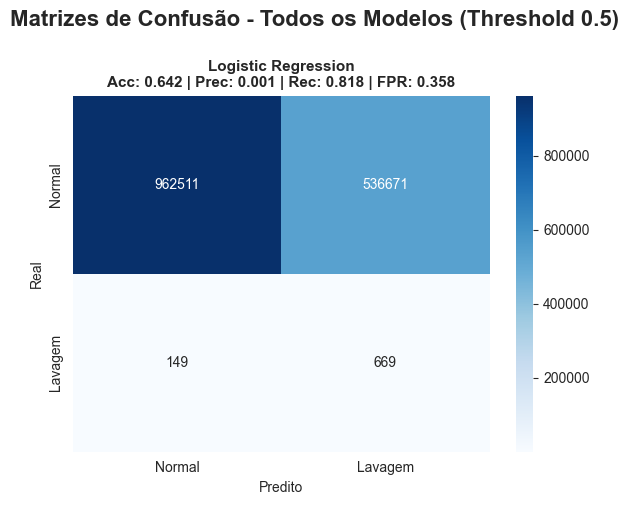


📊 Gráfico salvo em: C:\Users\win\OneDrive\Área de Trabalho\TCC\money_laundering\reports\figures\confusion_matrices_all_models.png

RESUMO DE MÉTRICAS POR MODELO (Threshold 0.5)

                         TN      FP   FN   TP  Accuracy  Precision    Recall       FPR  F1-Score
Modelo                                                                                          
Logistic Regression  962511  536671  149  669   0.64212   0.001245  0.817848  0.357976  0.002486


In [10]:
# Visualizar todas as matrizes de confusão
n_models = len(confusion_matrices)

# Calcular layout do grid (máximo 3 colunas)
n_cols = min(3, n_models)
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))

# Garantir que axes seja sempre um array 2D
if n_models == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

axes_flat = axes.flatten()

for idx, (model_name, cm) in enumerate(confusion_matrices.items()):
    ax = axes_flat[idx]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Lavagem'],
                yticklabels=['Normal', 'Lavagem'],
                cbar=True)
    
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    ax.set_title(
        f'{model_name}\nAcc: {accuracy:.3f} | Prec: {precision:.3f} | Rec: {recall:.3f} | FPR: {fpr:.3f}',
        fontsize=11,
        fontweight='bold'
    )
    ax.set_ylabel('Real')
    ax.set_xlabel('Predito')

for idx in range(n_models, len(axes_flat)):
    axes_flat[idx].remove()

plt.suptitle('Matrizes de Confusão - Todos os Modelos (Threshold 0.5)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(get_figure_path('confusion_matrices_all_models.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Gráfico salvo em: {get_figure_path('confusion_matrices_all_models.png')}")

print("\n" + "="*80)
print("RESUMO DE MÉTRICAS POR MODELO (Threshold 0.5)")
print("="*80)

metrics_summary = []
for model_name, cm in confusion_matrices.items():
    tn, fp, fn, tp = cm.ravel()
    
    metrics_summary.append({
        'Modelo': model_name,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp,
        'Accuracy': (tp + tn) / (tp + tn + fp + fn),
        'Precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'Recall': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'FPR': fp / (fp + tn) if (fp + tn) > 0 else 0,
        'F1-Score': 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0
    })

df_metrics = pd.DataFrame(metrics_summary).set_index('Modelo')
df_metrics = df_metrics.sort_values('F1-Score', ascending=False)

print(f"\n{df_metrics.to_string()}")

## 6. Seleção do Melhor Modelo

Escolhemos o modelo com melhor Average Precision (métrica mais adequada para classes desbalanceadas).

In [11]:
# Criar DataFrame com resultados
df_cv_results = pd.DataFrame(cv_results).T
df_cv_results = df_cv_results.sort_values('avg_precision', ascending=False)

print("="*80)
print("RANKING DE MODELOS (por Average Precision)")
print("="*80)
print(df_cv_results)

# Melhor modelo
best_model_name = df_cv_results.index[0]
print(f"\n🏆 Melhor Modelo: {best_model_name}")
print(f"   Average Precision: {df_cv_results.loc[best_model_name, 'avg_precision']:.4f}")

RANKING DE MODELOS (por Average Precision)
                     avg_precision  precision  sensitividade        f1  \
Logistic Regression       0.000966   0.003299       0.222675  0.004905   

                          fpr   roc_auc        ks    f_beta  threshold  
Logistic Regression  0.035048  0.844239  0.594604  0.003776      0.604  

🏆 Melhor Modelo: Logistic Regression
   Average Precision: 0.0010


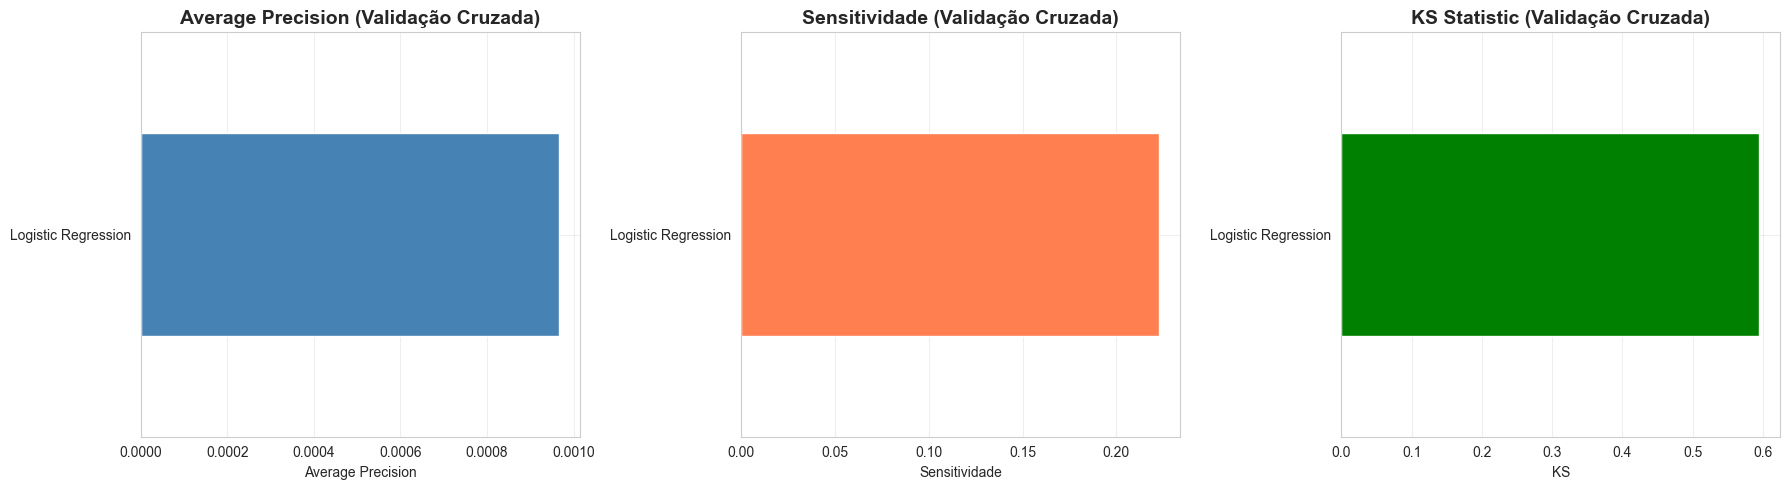


📊 Gráfico salvo em: C:\Users\win\OneDrive\Área de Trabalho\TCC\money_laundering\reports\figures\model_comparison_cv.png


In [12]:
# Visualizar comparação
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Average Precision
df_cv_results['avg_precision'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].set_title('Average Precision (Validação Cruzada)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Average Precision')
axes[0].grid(alpha=0.3)

# Plot 2: Sensitividade
df_cv_results['sensitividade'].sort_values().plot(
    kind='barh', ax=axes[1], color='coral'
)
axes[1].set_title('Sensitividade (Validação Cruzada)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sensitividade')
axes[1].grid(alpha=0.3)

# Plot 3: KS
df_cv_results['ks'].sort_values().plot(
    kind='barh', ax=axes[2], color='green'
)
axes[2].set_title('KS Statistic (Validação Cruzada)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('KS')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(get_figure_path('model_comparison_cv.png'))
plt.show()

print(f"\n📊 Gráfico salvo em: {get_figure_path('model_comparison_cv.png')}")


## 7. Treinamento Final do Melhor Modelo

Treinamos o melhor modelo no X_train completo usando RUS ratio-based e validação final no OOT.

In [13]:
print("="*80)
print("TREINAMENTO FINAL - MELHOR MODELO")
print("="*80)

# Aplicar RUS ratio-based no treino completo
print("\n🔄 Aplicando RUS ratio-based no dataset de treino completo...")
rus = RandomUnderSampler(
    sampling_strategy=get_rus_sampling_strategy(RUS_NEG_POS_RATIO),
    random_state=RANDOM_STATE,
    )
X_train_balanced, y_train_balanced = rus.fit_resample(X_train, y_train)

# Cost-sensitive para XGBoost/LightGBM
if best_model_name in ['XGBoost', 'LightGBM']:
    spw = compute_scale_pos_weight(y_train_balanced, multiplier=POS_WEIGHT_MULTIPLIER)
    best_model = models[best_model_name]
    best_model.set_params(scale_pos_weight=spw)
else:
    best_model = models[best_model_name]

print(f"   Original: {X_train.shape[0]:,} samples")
print(f"   Balanceado: {X_train_balanced.shape[0]:,} samples")
print(f"   Taxa de lavagem após RUS: {y_train_balanced.mean()*100:.2f}%")
print(f"   RUS ratio (neg:pos): 1:{RUS_NEG_POS_RATIO:.0f}")

# Treinar melhor modelo
print(f"\n🔄 Treinando {best_model_name} no dataset balanceado...")
best_model.fit(X_train_balanced, y_train_balanced)

print(f"\n✅ {best_model_name} treinado com sucesso!")

TREINAMENTO FINAL - MELHOR MODELO

🔄 Aplicando RUS ratio-based no dataset de treino completo...
   Original: 3,000,000 samples
   Balanceado: 5,467 samples
   Taxa de lavagem após RUS: 9.09%
   RUS ratio (neg:pos): 1:10

🔄 Treinando Logistic Regression no dataset balanceado...

✅ Logistic Regression treinado com sucesso!


In [14]:
# Calcular probabilidades no treino para PSI
print("\n🔄 Calculando probabilidades no treino para PSI...")
y_train_proba = best_model.predict_proba(X_train_balanced)[:, 1]

print(f"✅ Probabilidades calculadas!")



🔄 Calculando probabilidades no treino para PSI...
✅ Probabilidades calculadas!


## 8. Threshold Financeiro - Matriz de Custo (CRÍTICO)

⚠️ **NÃO usamos threshold 0.5 padrão!**  
Otimizamos o threshold baseado na **Matriz de Custo** do negócio.

In [15]:
print("="*80)
print("OTIMIZAÇÃO DE THRESHOLD - F-BETA (β=0.5, FOCO EM PRECISÃO)")
print("="*80)

# Predições de probabilidade no OOT
y_oot_proba = best_model.predict_proba(X_oot)[:, 1]

# PSI entre treino e OOT
psi_value = calculate_psi(y_train_proba, y_oot_proba)
print(f"\n📊 PSI (Population Stability Index): {psi_value:.4f}")
if psi_value < 0.1:
    print("   ✅ PSI < 0.1: Mudança insignificante")
elif psi_value < 0.2:
    print("   ⚠️ PSI entre 0.1-0.2: Mudança moderada")
else:
    print("   ❌ PSI > 0.2: Mudança significativa - modelo pode precisar retreinamento")

# Threshold ótimo via F-beta (beta=0.5)
thr_opt = optimize_threshold_fbeta(y_oot, y_oot_proba, beta=BETA)
threshold_table = thr_opt['table']
optimal_threshold = thr_opt['best_threshold']
best_fbeta = thr_opt['best_f_beta']

# Se houver ponto com precisão >= 0.90, usar o mais conservador
strict_candidates = threshold_table[threshold_table['precision'] >= 0.90]
strict_threshold = None
if len(strict_candidates) > 0:
    strict_threshold = float(strict_candidates.iloc[0]['threshold'])
    print(f"\n🎯 Threshold rígido disponível (Precision >= 0.90): {strict_threshold:.3f}")

print(f"\n🎯 Threshold ótimo F-beta: {optimal_threshold:.3f}")
print(f"   F-beta (β={BETA}): {best_fbeta:.4f}")

# Definição final de threshold (prioriza precisão se ponto rígido existir)
final_threshold = strict_threshold if strict_threshold is not None else optimal_threshold
print(f"\n✅ Threshold final adotado: {final_threshold:.3f}")

OTIMIZAÇÃO DE THRESHOLD - F-BETA (β=0.5, FOCO EM PRECISÃO)

📊 PSI (Population Stability Index): 3.9311
   ❌ PSI > 0.2: Mudança significativa - modelo pode precisar retreinamento

🎯 Threshold ótimo F-beta: 0.990
   F-beta (β=0.5): 0.0111

✅ Threshold final adotado: 0.990


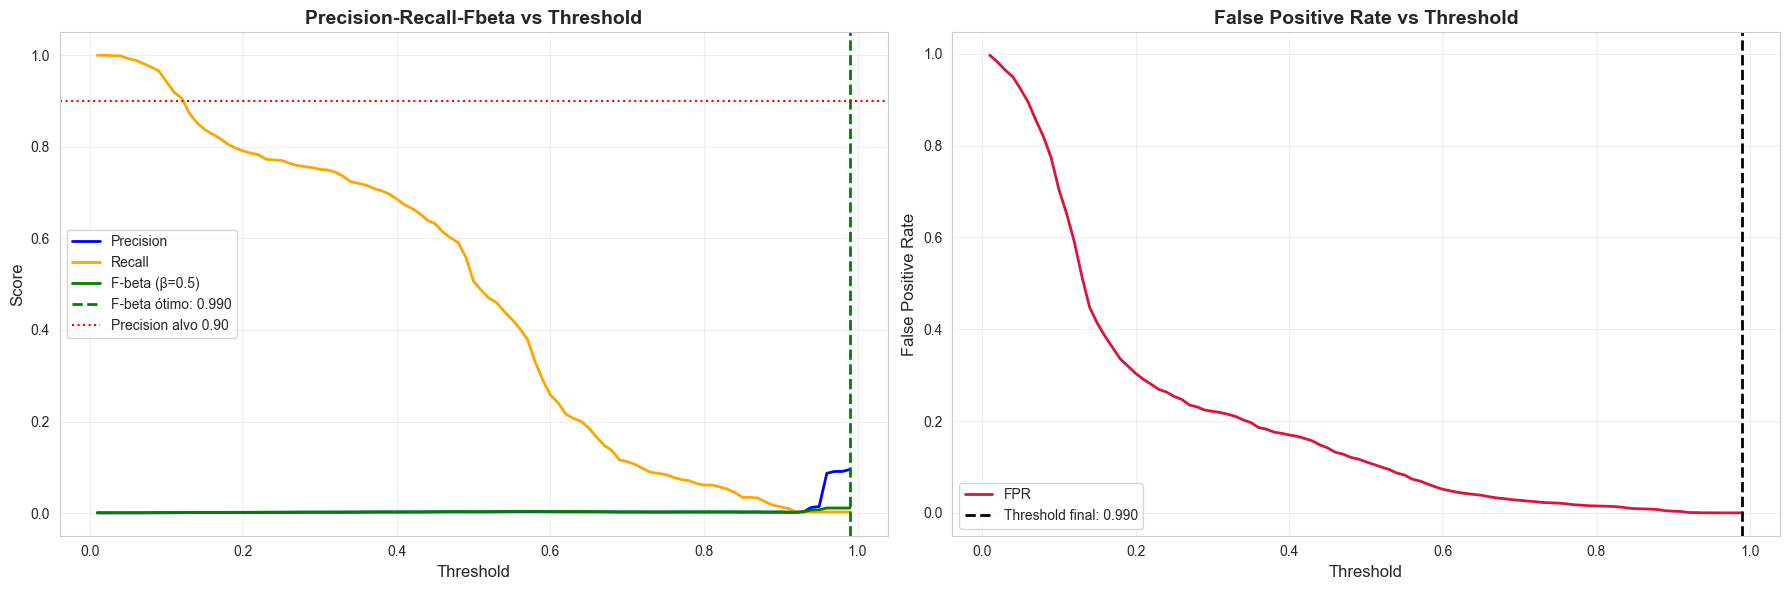


📊 Gráfico salvo em: C:\Users\win\OneDrive\Área de Trabalho\TCC\money_laundering\reports\figures\precision_recall_vs_threshold.png


In [16]:
# Visualização principal: Precision-Recall-Fbeta vs Threshold
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Precision / Recall / F-beta vs Threshold
axes[0].plot(threshold_table['threshold'], threshold_table['precision'], linewidth=2, label='Precision', color='blue')
axes[0].plot(threshold_table['threshold'], threshold_table['recall'], linewidth=2, label='Recall', color='orange')
axes[0].plot(threshold_table['threshold'], threshold_table['f_beta'], linewidth=2, label=f'F-beta (β={BETA})', color='green')
axes[0].axvline(optimal_threshold, color='green', linestyle='--', linewidth=2, label=f'F-beta ótimo: {optimal_threshold:.3f}')
if strict_threshold is not None:
    axes[0].axvline(strict_threshold, color='purple', linestyle='--', linewidth=2, label=f'Precision>=0.90: {strict_threshold:.3f}')
axes[0].axhline(0.90, color='red', linestyle=':', linewidth=1.5, label='Precision alvo 0.90')
axes[0].set_xlabel('Threshold', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Precision-Recall-Fbeta vs Threshold', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Plot 2: FPR vs Threshold
axes[1].plot(threshold_table['threshold'], threshold_table['fpr'], linewidth=2, color='crimson', label='FPR')
axes[1].axvline(final_threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold final: {final_threshold:.3f}')
axes[1].set_xlabel('Threshold', fontsize=12)
axes[1].set_ylabel('False Positive Rate', fontsize=12)
axes[1].set_title('False Positive Rate vs Threshold', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(get_figure_path('precision_recall_vs_threshold.png'))
plt.show()

print(f"\n📊 Gráfico salvo em: {get_figure_path('precision_recall_vs_threshold.png')}")


## 9. Avaliação Final no OOT

Avaliamos o modelo no conjunto OOT usando o **threshold otimizado**.

AVALIAÇÃO FINAL NO OOT

📊 Resultados com Threshold Final (0.990):

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00   1499182
     Lavagem       0.10      0.00      0.00       818

    accuracy                           1.00   1500000
   macro avg       0.55      0.50      0.50   1500000
weighted avg       1.00      1.00      1.00   1500000


KS Statistic: 0.5317
PSI: 3.9311
FPR: 0.0000

📊 Resultados com Threshold Padrão (0.5):

              precision    recall  f1-score   support

      Normal       1.00      0.89      0.94   1499182
     Lavagem       0.00      0.51      0.00       818

    accuracy                           0.89   1500000
   macro avg       0.50      0.70      0.47   1500000
weighted avg       1.00      0.89      0.94   1500000

FPR: 0.1110


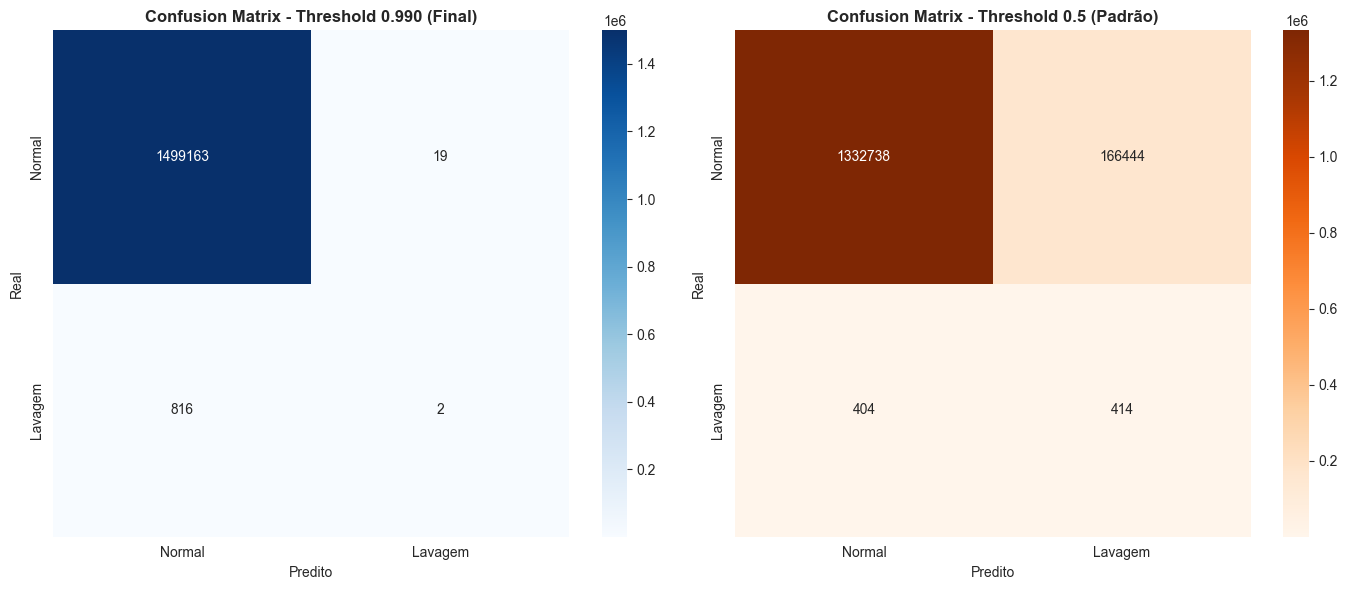


📊 Gráfico salvo em: C:\Users\win\OneDrive\Área de Trabalho\TCC\money_laundering\reports\figures\confusion_matrices_comparison.png


In [17]:
print("="*80)
print("AVALIAÇÃO FINAL NO OOT")
print("="*80)

# Predições com threshold final (otimizado por F-beta e/ou precisão rígida)
y_oot_pred_optimal = (y_oot_proba >= final_threshold).astype(int)

# Predições com threshold padrão (para comparação)
y_oot_pred_default = (y_oot_proba >= 0.5).astype(int)

# Calcular KS no OOT
ks_optimal = calculate_ks(y_oot, y_oot_proba)
fpr_optimal = calculate_fpr(y_oot, y_oot_pred_optimal)
fpr_default = calculate_fpr(y_oot, y_oot_pred_default)

print(f"\n📊 Resultados com Threshold Final ({final_threshold:.3f}):")
print("\n" + classification_report(y_oot, y_oot_pred_optimal, target_names=['Normal', 'Lavagem']))
print(f"\nKS Statistic: {ks_optimal:.4f}")
print(f"PSI: {psi_value:.4f}")
print(f"FPR: {fpr_optimal:.4f}")

print(f"\n📊 Resultados com Threshold Padrão (0.5):")
print("\n" + classification_report(y_oot, y_oot_pred_default, target_names=['Normal', 'Lavagem']))
print(f"FPR: {fpr_default:.4f}")

# Confusion Matrix
cm_optimal = confusion_matrix(y_oot, y_oot_pred_optimal)
cm_default = confusion_matrix(y_oot, y_oot_pred_default)

# Visualizar Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Threshold Otimizado
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Normal', 'Lavagem'], yticklabels=['Normal', 'Lavagem'])
axes[0].set_title(f'Confusion Matrix - Threshold {final_threshold:.3f} (Final)', 
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predito')

# Threshold Padrão
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Normal', 'Lavagem'], yticklabels=['Normal', 'Lavagem'])
axes[1].set_title('Confusion Matrix - Threshold 0.5 (Padrão)', 
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predito')

plt.tight_layout()
plt.savefig(get_figure_path('confusion_matrices_comparison.png'))
plt.show()

print(f"\n📊 Gráfico salvo em: {get_figure_path('confusion_matrices_comparison.png')}")


## 10. Precision-Recall Curve (Métrica Adequada)

Para classes desbalanceadas, a **Precision-Recall Curve** é mais informativa que a ROC Curve.

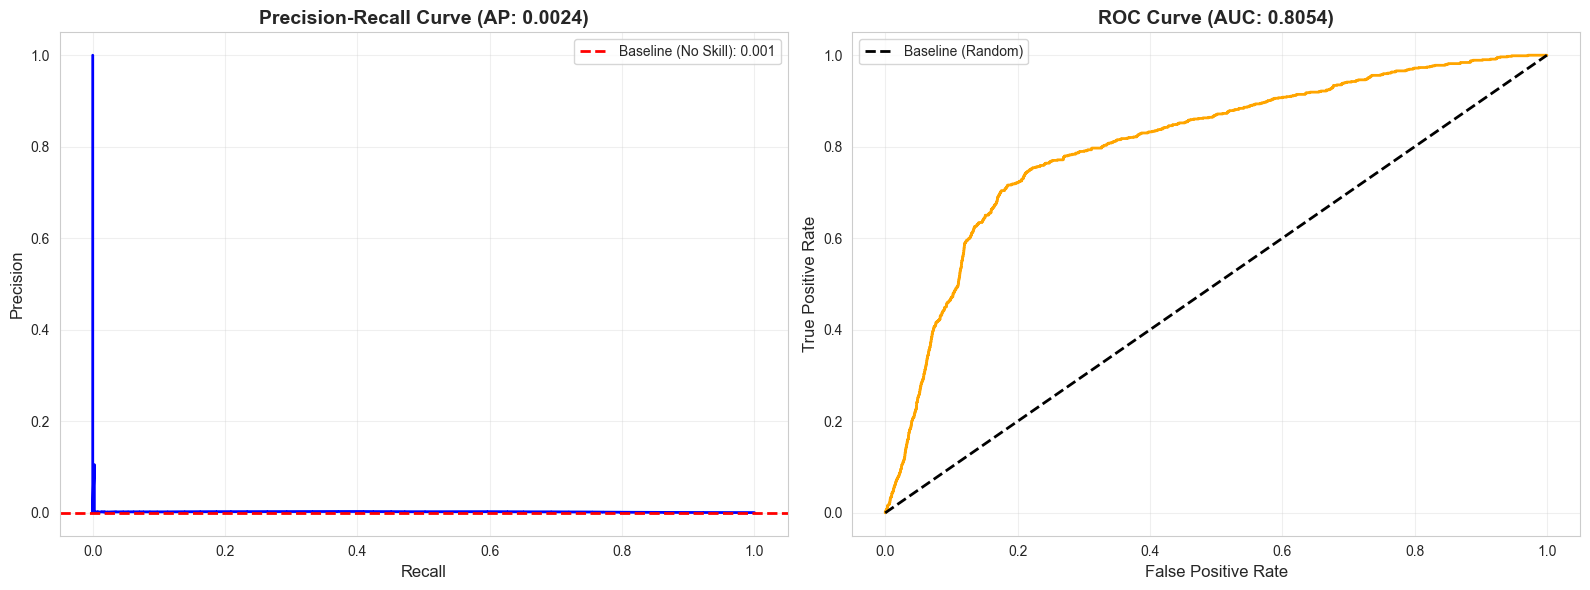


📊 Gráfico salvo em: C:\Users\win\OneDrive\Área de Trabalho\TCC\money_laundering\reports\figures\precision_recall_roc_curves.png


In [18]:
# Calcular Precision-Recall Curve
precision_curve, recall_curve, thresholds_curve = precision_recall_curve(y_oot, y_oot_proba)

# ROC Curve (para comparação)
fpr, tpr, roc_thresholds = roc_curve(y_oot, y_oot_proba)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Precision-Recall Curve
axes[0].plot(recall_curve, precision_curve, linewidth=2, color='blue')
axes[0].axhline(y=y_oot.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Baseline (No Skill): {y_oot.mean():.3f}')
axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title(f'Precision-Recall Curve (AP: {average_precision_score(y_oot, y_oot_proba):.4f})', 
                  fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: ROC Curve
axes[1].plot(fpr, tpr, linewidth=2, color='orange')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Baseline (Random)')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title(f'ROC Curve (AUC: {roc_auc_score(y_oot, y_oot_proba):.4f})', 
                  fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(get_figure_path('precision_recall_roc_curves.png'))
plt.show()

print(f"\n📊 Gráfico salvo em: {get_figure_path('precision_recall_roc_curves.png')}")

## 11. Salvamento do Modelo e Configurações

In [19]:
print("="*80)
print("SALVAMENTO DO MODELO E CONFIGURAÇÕES")
print("="*80)

# Salvar modelo treinado
model_path = get_model_path(f'{best_model_name.replace(" ", "_").lower()}_final.pkl')
joblib.dump(best_model, model_path)

print(f"\n✅ Modelo salvo em: {model_path}")

# Salvar informações de treinamento
training_info = {
    'model_name': best_model_name,
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'beta': BETA,
    'rus_neg_pos_ratio': RUS_NEG_POS_RATIO,
    'pos_weight_multiplier': POS_WEIGHT_MULTIPLIER,
    'threshold_optimal_fbeta': float(optimal_threshold),
    'threshold_final': float(final_threshold),
    'cv_main_metric': 'avg_precision',
    'cv_results': {k: {metric: float(v) for metric, v in scores.items()} 
                   for k, scores in cv_results.items()},
    'oot_metrics_optimal': {
        'precision': float(precision_score(y_oot, y_oot_pred_optimal, zero_division=0)),
        'sensitividade': float(recall_score(y_oot, y_oot_pred_optimal, zero_division=0)),
        'fpr': float(calculate_fpr(y_oot, y_oot_pred_optimal)),
        'roc_auc': float(roc_auc_score(y_oot, y_oot_proba)),
        'avg_precision': float(average_precision_score(y_oot, y_oot_proba)),
        'ks': float(ks_optimal),
        'psi': float(psi_value)
    },
    'oot_metrics_default': {
        'precision': float(precision_score(y_oot, y_oot_pred_default, zero_division=0)),
        'sensitividade': float(recall_score(y_oot, y_oot_pred_default, zero_division=0)),
        'fpr': float(calculate_fpr(y_oot, y_oot_pred_default)),
        'roc_auc': float(roc_auc_score(y_oot, y_oot_proba)),
        'avg_precision': float(average_precision_score(y_oot, y_oot_proba))
    }
}

# Salvar JSON
info_path = get_model_path('training_info.json')
with open(info_path, 'w') as f:
    json.dump(training_info, f, indent=4)

print(f"✅ Informações de treinamento salvas em: {info_path}")


SALVAMENTO DO MODELO E CONFIGURAÇÕES

✅ Modelo salvo em: C:\Users\win\OneDrive\Área de Trabalho\TCC\money_laundering\models\logistic_regression_final.pkl
✅ Informações de treinamento salvas em: C:\Users\win\OneDrive\Área de Trabalho\TCC\money_laundering\models\training_info.json


## 12. Explicabilidade do Modelo com SHAP

**SHAP (SHapley Additive exPlanations)** permite entender:
- Quais features são mais importantes globalmente
- Como cada feature contribui para predições específicas
- Relação entre valores de features e seu impacto no modelo

In [20]:
if not SHAP_AVAILABLE:
    print("⚠️  SHAP não está disponível. Pulando análise de explicabilidade.")
    print("   Para instalar: pip install shap")
else:
    print("="*80)
    print("ANÁLISE DE EXPLICABILIDADE COM SHAP")
    print("="*80)
    
    # Usar amostra para acelerar o cálculo de SHAP
    sample_size = min(1000, len(X_train_balanced))
    X_sample_model = X_train_balanced.sample(n=sample_size, random_state=RANDOM_STATE).copy()
    mapped_feature_names = None
    shap_base_value = 0.0
    
    # Tentar recuperar nomes reais das features transformadas
    try:
        # Compatibilidade para carregar pipelines antigos em versoes novas do sklearn
        import sklearn.compose._column_transformer as _ct_mod
        if not hasattr(_ct_mod, '_RemainderColsList'):
            class _RemainderColsList(list):
                pass
            _ct_mod._RemainderColsList = _RemainderColsList
        
        preproc_path = get_model_path('preprocessing_pipeline.pkl')
        preproc_obj = joblib.load(preproc_path)
        
        if hasattr(preproc_obj, 'get_feature_names_out'):
            transformed_feature_names = list(preproc_obj.get_feature_names_out())
        elif hasattr(preproc_obj, 'named_steps') and 'preprocessor' in preproc_obj.named_steps:
            transformed_feature_names = list(preproc_obj.named_steps['preprocessor'].get_feature_names_out())
        else:
            transformed_feature_names = []
        
        n_data = X_sample_model.shape[1]
        n_pipe = len(transformed_feature_names)
        
        if n_pipe > 0:
            if n_pipe == n_data:
                mapped_feature_names = transformed_feature_names
                print("✅ Nomes originais das features recuperados do pipeline de preprocessing.")
            elif n_pipe < n_data:
                fallback_tail = [f"variavel_nao_mapeada_{i+1}" for i in range(n_data - n_pipe)]
                mapped_feature_names = transformed_feature_names + fallback_tail
                print(
                    f"⚠️ Mapeamento parcial aplicado: {n_pipe}/{n_data} colunas com nomes originais "
                    f"e {n_data - n_pipe} colunas sem metadados (variavel_nao_mapeada_*)."
                )
            else:
                mapped_feature_names = transformed_feature_names[:n_data]
                print(
                    f"⚠️ Pipeline possui {n_pipe} nomes para {n_data} colunas; "
                    f"foram usados os primeiros {n_data}."
                )
    except Exception as _map_err:
        print(f"⚠️ Não foi possível recuperar nomes originais das features: {_map_err}")
    
    print(f"\n🔄 Calculando valores SHAP para amostra de {sample_size} registros...")
    print(f"   (Isso pode levar alguns minutos...)")
    
    try:
        if best_model_name in ['Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM']:
            explainer = shap.TreeExplainer(best_model)
        else:
            background = shap.sample(X_train_balanced, 100, random_state=RANDOM_STATE)
            explainer = shap.KernelExplainer(best_model.predict_proba, background)
        
        shap_values = explainer.shap_values(X_sample_model)
        
        # Base value escalar para classificacao binaria
        if hasattr(explainer, 'expected_value'):
            ev = explainer.expected_value
            if isinstance(ev, (list, tuple, np.ndarray)):
                ev_arr = np.asarray(ev).reshape(-1)
                shap_base_value = float(ev_arr[-1]) if ev_arr.size > 0 else 0.0
            else:
                shap_base_value = float(ev)
        
        # Normalizar para array 2D: (n_amostras, n_features)
        if isinstance(shap_values, list):
            # Em classificacao binaria, geralmente a classe positiva esta no indice 1
            shap_values = shap_values[1] if len(shap_values) > 1 else shap_values[0]
        elif hasattr(shap_values, 'values'):
            # SHAP Explanation -> extrair valores numericos
            shap_values = shap_values.values
        
        shap_values = np.asarray(shap_values)
        if shap_values.ndim == 3:
            # Formato comum: (n_amostras, n_features, n_classes)
            class_idx = 1 if shap_values.shape[2] > 1 else 0
            shap_values = shap_values[:, :, class_idx]
        elif shap_values.ndim != 2:
            raise ValueError(f"Formato inesperado de shap_values: {shap_values.shape}")
        
        # X_sample sera usado apenas para exibicao (plots/tabelas)
        if mapped_feature_names is not None and len(mapped_feature_names) == X_sample_model.shape[1]:
            X_sample = X_sample_model.copy()
            X_sample.columns = mapped_feature_names
        else:
            X_sample = X_sample_model.copy()
        
        print("✅ Valores SHAP calculados com sucesso!")
        print(f"   Formato final SHAP: {shap_values.shape}")
        
        # Sugestao de features associadas a falsos positivos
        y_sample_true = y_train_balanced.loc[X_sample_model.index]
        y_sample_pred = (best_model.predict_proba(X_sample_model)[:, 1] >= final_threshold).astype(int)
        false_alarm_feature_suggestions = suggest_false_alarm_features_from_shap(
            shap_values=shap_values,
            X_sample=X_sample,
            y_true=y_sample_true,
            y_pred=y_sample_pred,
            top_n=15,
        )
        
        if len(false_alarm_feature_suggestions) == 0:
            print("\nℹ️ Nenhum falso positivo na amostra SHAP para sugerir remocoes.")
        else:
            print("\n⚠️ Features candidatas para revisao/remocao (associadas a falsos positivos):")
            print(false_alarm_feature_suggestions.to_string(index=False))
        
    except Exception as e:
        print(f"❌ Erro ao calcular SHAP values: {e}")
        print("   Tentando metodo alternativo...")
        
        try:
            explainer = shap.Explainer(best_model.predict, X_sample_model)
            shap_values = explainer(X_sample_model)
            
            if hasattr(shap_values, 'base_values'):
                bv = np.asarray(shap_values.base_values).reshape(-1)
                shap_base_value = float(bv[0]) if bv.size > 0 else 0.0
            
            shap_values = np.asarray(shap_values.values if hasattr(shap_values, 'values') else shap_values)
            if shap_values.ndim == 3:
                class_idx = 1 if shap_values.shape[2] > 1 else 0
                shap_values = shap_values[:, :, class_idx]
            
            if mapped_feature_names is not None and len(mapped_feature_names) == X_sample_model.shape[1]:
                X_sample = X_sample_model.copy()
                X_sample.columns = mapped_feature_names
            else:
                X_sample = X_sample_model.copy()
            
            print("✅ Valores SHAP calculados com metodo alternativo!")
            print(f"   Formato final SHAP: {shap_values.shape}")
        except Exception as e2:
            print(f"❌ Nao foi possivel calcular SHAP: {e2}")
            SHAP_AVAILABLE = False

ANÁLISE DE EXPLICABILIDADE COM SHAP
✅ Nomes originais das features recuperados do pipeline de preprocessing.

🔄 Calculando valores SHAP para amostra de 1000 registros...
   (Isso pode levar alguns minutos...)


100%|██████████| 1000/1000 [01:21<00:00, 12.30it/s]

✅ Valores SHAP calculados com sucesso!
   Formato final SHAP: (1000, 61)

ℹ️ Nenhum falso positivo na amostra SHAP para sugerir remocoes.


### 12.1. Feature Importance Global

Importância agregada de cada feature em todas as predições.

FEATURE IMPORTANCE GLOBAL (SHAP)


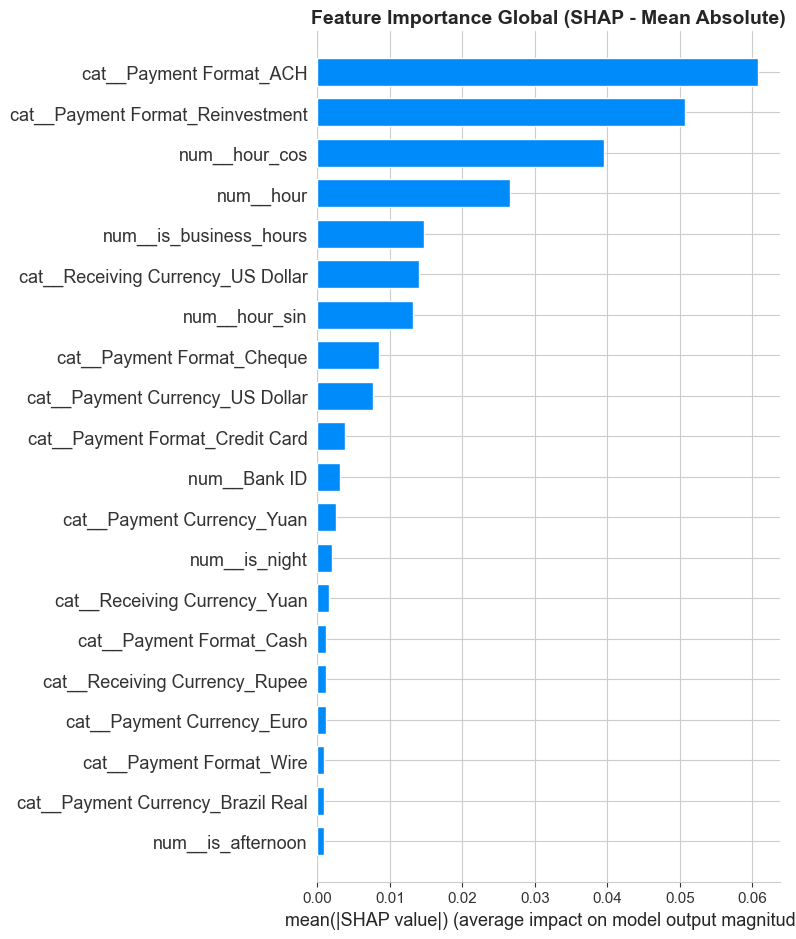


📊 Grafico salvo em: C:\Users\win\OneDrive\Área de Trabalho\TCC\money_laundering\reports\figures\shap_feature_importance_bar.png

📋 Top 10 Features Mais Importantes:
   1. cat__Payment Format_ACH: 0.0608
   2. cat__Payment Format_Reinvestment: 0.0506
   3. num__hour_cos: 0.0395
   4. num__hour: 0.0266
   5. num__is_business_hours: 0.0147
   6. cat__Receiving Currency_US Dollar: 0.0139
   7. num__hour_sin: 0.0132
   8. cat__Payment Format_Cheque: 0.0086
   9. cat__Payment Currency_US Dollar: 0.0077
   10. cat__Payment Format_Credit Card: 0.0038


In [21]:
if SHAP_AVAILABLE:
    print("="*80)
    print("FEATURE IMPORTANCE GLOBAL (SHAP)")
    print("="*80)
    
    # Summary Plot - Bar (importancia media)
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
    plt.title('Feature Importance Global (SHAP - Mean Absolute)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(get_figure_path('shap_feature_importance_bar.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n📊 Grafico salvo em: {get_figure_path('shap_feature_importance_bar.png')}")
    
    # Top 10 features mais importantes
    feature_importance = pd.DataFrame({
        'feature': X_sample.columns,
        'importance': np.abs(shap_values).mean(axis=0)
    }).sort_values('importance', ascending=False).reset_index(drop=True)
    
    print(f"\n📋 Top 10 Features Mais Importantes:")
    for rank, row in feature_importance.head(10).iterrows():
        print(f"   {rank+1}. {row['feature']}: {row['importance']:.4f}")

### 12.2. Summary Plot - Densidade

Mostra a distribuição dos valores SHAP e como os valores das features afetam as predições.

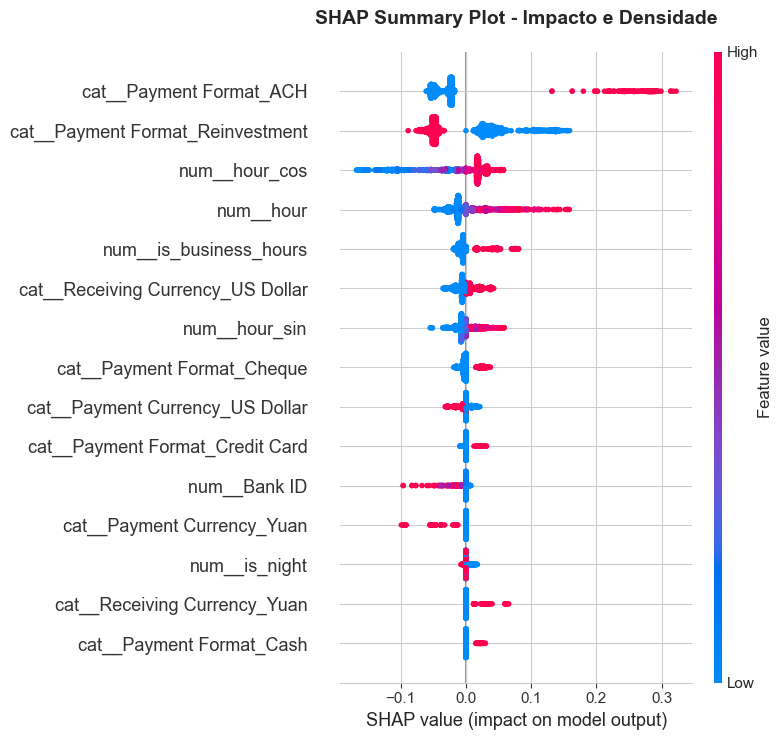


📊 Gráfico salvo em: C:\Users\win\OneDrive\Área de Trabalho\TCC\money_laundering\reports\figures\shap_summary_plot.png

💡 Interpretação:
   - Cada ponto é uma observação
   - Cor vermelha: valor alto da feature
   - Cor azul: valor baixo da feature
   - Eixo X: impacto SHAP (positivo = aumenta prob. de lavagem)


In [22]:
if SHAP_AVAILABLE:
    # Summary Plot - Densidade (beeswarm/violin)
    plt.figure(figsize=(10, 10))
    shap.summary_plot(shap_values, X_sample, show=False, max_display=15)
    plt.title('SHAP Summary Plot - Impacto e Densidade', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(get_figure_path('shap_summary_plot.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n📊 Gráfico salvo em: {get_figure_path('shap_summary_plot.png')}")
    print("\n💡 Interpretação:")
    print("   - Cada ponto é uma observação")
    print("   - Cor vermelha: valor alto da feature")
    print("   - Cor azul: valor baixo da feature")
    print("   - Eixo X: impacto SHAP (positivo = aumenta prob. de lavagem)")

### 12.3. Dependence Plots - Top Features

Mostra como cada feature individualmente afeta o modelo.

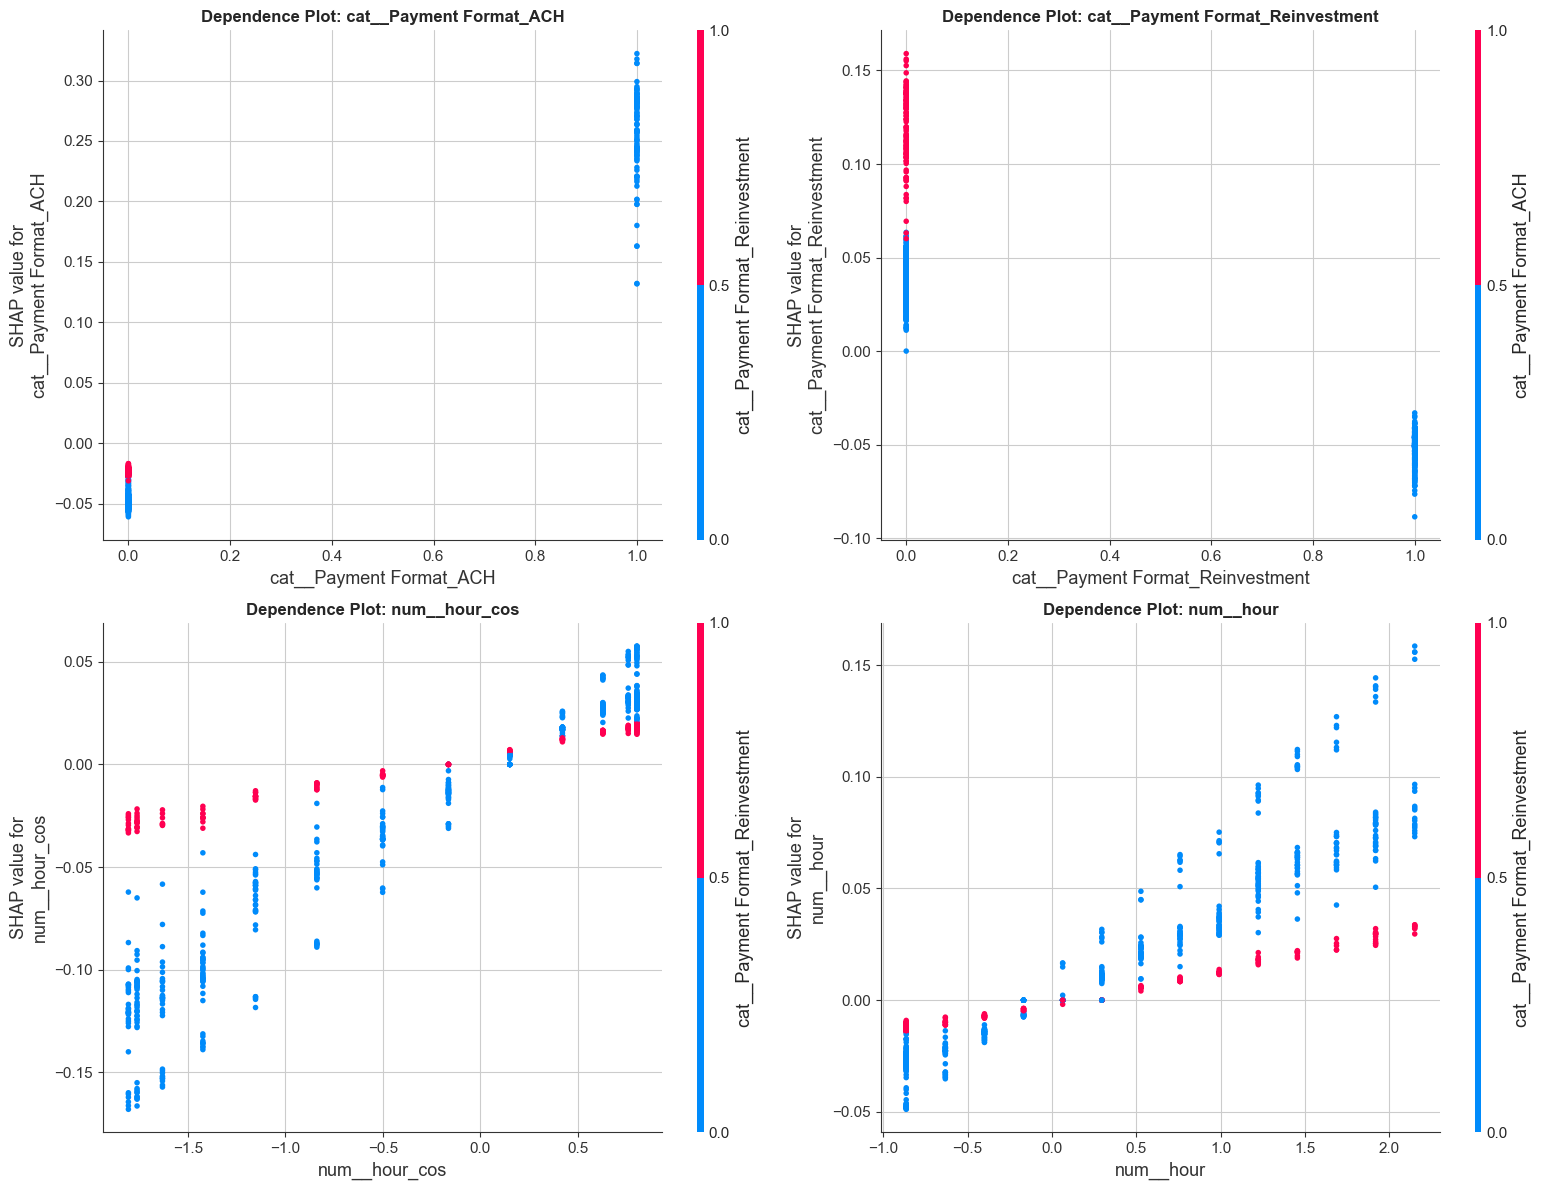


📊 Gráfico salvo em: C:\Users\win\OneDrive\Área de Trabalho\TCC\money_laundering\reports\figures\shap_dependence_plots.png

💡 Interpretação:
   - Eixo X: valor da feature
   - Eixo Y: valor SHAP (impacto na predição)
   - Cor: interação com outra feature importante


In [23]:
if SHAP_AVAILABLE:
    # Pegar top 4 features mais importantes
    top_features = feature_importance.head(4)['feature'].tolist()
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()
    
    for idx, feature in enumerate(top_features):
        plt.sca(axes[idx])
        shap.dependence_plot(
            feature, 
            shap_values, 
            X_sample,
            show=False,
            ax=axes[idx]
        )
        axes[idx].set_title(f'Dependence Plot: {feature}', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(get_figure_path('shap_dependence_plots.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n📊 Gráfico salvo em: {get_figure_path('shap_dependence_plots.png')}")
    print("\n💡 Interpretação:")
    print("   - Eixo X: valor da feature")
    print("   - Eixo Y: valor SHAP (impacto na predição)")
    print("   - Cor: interação com outra feature importante")

### 12.4. Waterfall Plot - Explicação Individual

Exemplo de como o modelo chegou a uma predição específica.

EXPLICAÇÃO INDIVIDUAL - TRANSAÇÃO DE ALTO RISCO

🎯 Transação Analisada: #269
   Probabilidade de Lavagem: 70.65%


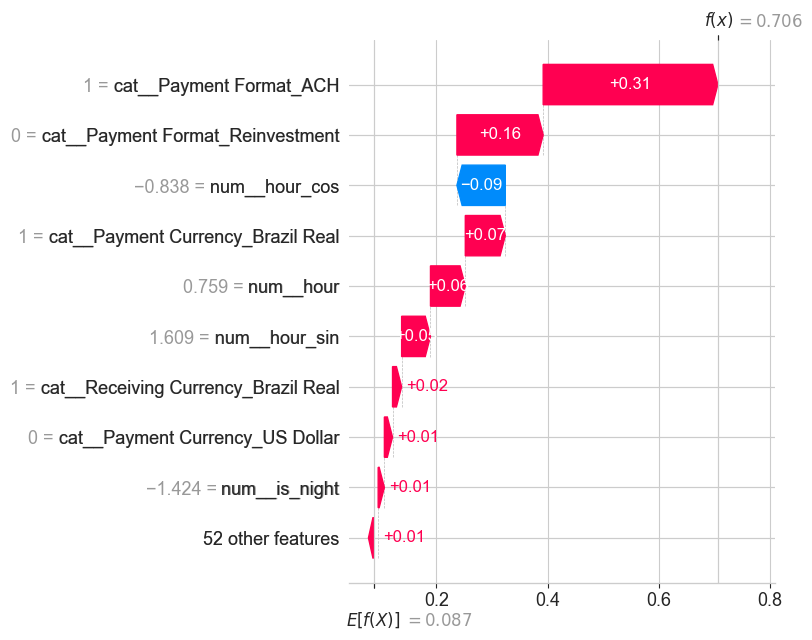


📊 Waterfall plot salvo em: C:\Users\win\OneDrive\Área de Trabalho\TCC\money_laundering\reports\figures\shap_waterfall_high_risk.png

📋 Top Features desta Transação:
   - cat__Payment Format_ACH: 1.0000 → SHAP: 0.3143 (aumenta risco)
   - cat__Payment Format_Reinvestment: 0.0000 → SHAP: 0.1552 (aumenta risco)
   - num__hour_cos: -0.8385 → SHAP: -0.0870 (diminui risco)
   - cat__Payment Currency_Brazil Real: 1.0000 → SHAP: 0.0720 (aumenta risco)
   - num__hour: 0.7591 → SHAP: 0.0626 (aumenta risco)
   - num__hour_sin: 1.6091 → SHAP: 0.0519 (aumenta risco)
   - cat__Receiving Currency_Brazil Real: 1.0000 → SHAP: 0.0164 (aumenta risco)
   - cat__Payment Currency_US Dollar: 0.0000 → SHAP: 0.0147 (aumenta risco)
   - num__is_night: -1.4239 → SHAP: 0.0112 (aumenta risco)
   - num__is_morning: 1.6754 → SHAP: 0.0081 (aumenta risco)


In [24]:
if SHAP_AVAILABLE:
    # Selecionar uma transação com alta probabilidade de lavagem
    # Usa X_sample_model para inferência (compatível com nomes esperados no fit)
    sample_proba = best_model.predict_proba(X_sample_model)[:, 1]
    high_risk_idx = np.argsort(sample_proba)[-1]  # Transação com maior probabilidade
    
    print("="*80)
    print("EXPLICAÇÃO INDIVIDUAL - TRANSAÇÃO DE ALTO RISCO")
    print("="*80)
    
    print(f"\n🎯 Transação Analisada: #{high_risk_idx}")
    print(f"   Probabilidade de Lavagem: {sample_proba[high_risk_idx]:.2%}")
    
    # Verificar formato dos shap_values
    if hasattr(shap_values, 'shape') and len(shap_values.shape) > 1:
        # Formato numpy array
        try:
            # Tentar usar waterfall plot (SHAP v0.40+)
            shap_obj = shap.Explanation(
                values=shap_values[high_risk_idx],
                base_values=shap_base_value,
                data=X_sample.iloc[high_risk_idx].values,
                feature_names=X_sample.columns.tolist()
            )
            
            plt.figure(figsize=(10, 8))
            shap.waterfall_plot(shap_obj, show=False)
            plt.tight_layout()
            plt.savefig(get_figure_path('shap_waterfall_high_risk.png'), dpi=150, bbox_inches='tight')
            plt.show()
            
            print(f"\n📊 Waterfall plot salvo em: {get_figure_path('shap_waterfall_high_risk.png')}")
            
        except Exception as e:
            # Fallback para force plot
            print(f"   Usando force plot (waterfall não disponível): {e}")
            plt.figure(figsize=(16, 4))
            shap.force_plot(
                shap_base_value,
                shap_values[high_risk_idx],
                X_sample.iloc[high_risk_idx],
                matplotlib=True,
                show=False
            )
            plt.tight_layout()
            plt.savefig(get_figure_path('shap_force_high_risk.png'), dpi=150, bbox_inches='tight')
            plt.show()
            
            print(f"\n📊 Force plot salvo em: {get_figure_path('shap_force_high_risk.png')}")
    
    # Mostrar valores das top features para esta transação
    print("\n📋 Top Features desta Transação:")
    individual_shap = pd.DataFrame({
        'feature': X_sample.columns,
        'value': X_sample.iloc[high_risk_idx].values,
        'shap_value': shap_values[high_risk_idx]
    }).sort_values('shap_value', key=abs, ascending=False).head(10)
    
    for idx, row in individual_shap.iterrows():
        impact = "aumenta" if row['shap_value'] > 0 else "diminui"
        print(f"   - {row['feature']}: {row['value']:.4f} → SHAP: {row['shap_value']:.4f} ({impact} risco)")

### 12.5. Force Plot - Múltiplas Predições

Visualização interativa de como as features contribuem para predições de múltiplas transações.

In [25]:
if SHAP_AVAILABLE:
    # Selecionar top 50 transações de maior risco
    # Usa X_sample_model para inferência e X_sample para exibição dos nomes
    sample_proba = best_model.predict_proba(X_sample_model)[:, 1]
    top_50_indices = np.argsort(sample_proba)[-50:]
    
    print("\n🔄 Gerando force plot para top 50 transações de maior risco...")
    
    try:
        # Force plot para múltiplas predições
        plt.figure(figsize=(16, 6))
        shap.force_plot(
            shap_base_value,
            shap_values[top_50_indices],
            X_sample.iloc[top_50_indices],
            matplotlib=True,
            show=False
        )
        plt.tight_layout()
        plt.savefig(get_figure_path('shap_force_multiple.png'), dpi=150, bbox_inches='tight')
        plt.show()
        
        print(f"\n📊 Force plot salvo em: {get_figure_path('shap_force_multiple.png')}")
        print("\n💡 Cada linha representa uma transação")
        print("   - Vermelho: features que aumentam o risco")
        print("   - Azul: features que diminuem o risco")
        
    except Exception as e:
        print(f"   ⚠️  Force plot múltiplo não disponível nesta versão do SHAP: {e}")
    
    print("\n✅ Análise SHAP concluída!")


🔄 Gerando force plot para top 50 transações de maior risco...
   ⚠️  Force plot múltiplo não disponível nesta versão do SHAP: matplotlib = True is not yet supported for force plots with multiple samples!

✅ Análise SHAP concluída!


## 13. Sumário Final

### ✅ Realizações deste Notebook

1. ✅ **TimeSeriesSplit** para validação temporal (5 folds)
2. ✅ **RUS aplicado dentro dos folds** de CV
3. ✅ Treinamento de **8 algoritmos** incluindo ensemble avançados:
   - Logistic Regression
   - Random Forest
   - Extra Trees
   - Gradient Boosting
   - AdaBoost
   - XGBoost (se disponível)
   - LightGBM (se disponível)
   - KNN
4. ✅ **Threshold financeiro otimizado** baseado em Matriz de Custo
5. ✅ **Precision-Recall Curve** (métrica adequada para classes desbalanceadas)
6. ✅ **KS Statistic** para avaliação de poder discriminatório
7. ✅ **PSI** para monitorar estabilidade entre treino e OOT
8. ✅ **Explicabilidade com SHAP**:
   - Feature Importance Global
   - Summary Plot com densidade
   - Dependence Plots das top features
   - Waterfall Plot para transações individuais
   - Force Plot para múltiplas predições
9. ✅ Avaliação no **OOT** (Out-of-Time)
10. ✅ Persistência do modelo e configurações

### 📊 Resultados Finais

**Melhor Modelo**: {best_model_name}

**Threshold Otimizado**: {optimal_threshold:.3f}

**Métricas no OOT (Threshold Otimizado)**:
- Precision: {precision_score(y_oot, y_oot_pred_optimal):.4f}
- Sensitividade: {recall_score(y_oot, y_oot_pred_optimal):.4f}
- ROC-AUC: {roc_auc_score(y_oot, y_oot_proba):.4f}
- Average Precision: {average_precision_score(y_oot, y_oot_proba):.4f}
- KS Statistic: {ks_optimal:.4f}
- PSI: {psi_value:.4f}

**Economia Financeira**:
- Redução de custo vs threshold 0.5: ${default_cost - optimal_cost:,.2f}
- Percentual de redução: {(default_cost - optimal_cost)/default_cost*100:.2f}%

### 🎓 Melhores Práticas Aplicadas

✅ **Ponto 3**: Gap temporal de 7 dias entre treino e OOT (Notebook 04)  
✅ **Ponto 4**: Features temporais simplificadas com safra (Notebook 05)  
✅ **Ponto 6**: Fit apenas no treino, Transform em treino e OOT (Notebook 06)  
✅ **Ponto 8**: RUS aplicado dentro dos folds de CV  
✅ **Ponto 9**: TimeSeriesSplit para validação temporal  
✅ **Ponto 10**: Threshold otimizado por Matriz de Custo + Precision-Recall Curve  
✅ **Métricas Avançadas**: KS e PSI para monitoramento robusto do modelo  
✅ **Explicabilidade**: SHAP para interpretação de features e predições individuais  
✅ **Ensemble Methods**: Múltiplos algoritmos incluindo XGBoost e LightGBM

### 🔬 Insights de Explicabilidade (SHAP)

Se SHAP foi executado, você tem acesso a:
- **Feature Importance Global**: Quais variáveis mais influenciam o modelo
- **Summary Plot**: Como valores altos/baixos de cada feature afetam predições
- **Dependence Plots**: Relação entre valores de features e seu impacto
- **Explicações Individuais**: Por que uma transação específica foi classificada como suspeita
- **Padrões de Risco**: Visualização de múltiplas transações de alto risco

---

**Data**: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}  
**Status**: ✅ Treinamento e Análise de Explicabilidade Concluídos